In [3]:
# CAPSTONE PROJECT
# TELCO CUSTOMER CHURN PREDICTION

#BUSINESS PROBLEM:

#Customer churn is one of the biggest challenges in the telecom industry.

#Acquiring new customers is significantly more expensive than retaining 
#existing customers. Therefore, predicting customers who are likely to 
#leave the telecom service helps companies:

#1. Reduce customer attrition
#2. Improve customer retention strategies
#3. Increase long-term profitability
#4. Identify high-risk customers early
#5. Optimize marketing and support efforts

#OBJECTIVE:

#Build a machine learning classification system to predict whether a 
#customer is likely to churn based on:

#- Demographic information
#- Service subscriptions
#- Account details
#- Billing information
#- Customer tenure

#The project will compare multiple classification algorithms and identify 
#the best-performing model for churn prediction.

In [5]:

# Data Handling
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Warnings
import warnings
warnings.filterwarnings('ignore')

# Display Settings
pd.set_option('display.max_columns', None)

# Style
sns.set_style('whitegrid')

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [7]:

df = pd.read_csv("Telco_Customer_Churn.csv")

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [9]:

display(df.head())

print("\nDataset Shape:")

print(df.shape)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes



Dataset Shape:
(7043, 21)


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [13]:
display(df.describe())

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [15]:

missing_values = pd.DataFrame({

    'Missing Count': df.isnull().sum(),

    'Missing Percentage': (
        df.isnull().sum() / len(df)
    ) * 100
})

display(
    missing_values[
        missing_values['Missing Count'] > 0
    ]
)

,Missing Count,Missing Percentage


In [17]:

blank_values = (
    df == ' '
).sum()

blank_values[
    blank_values > 0
]

TotalCharges    11
dtype: int64

In [19]:
print(df['TotalCharges'].head(20))

print("\nDatatype:")

print(df['TotalCharges'].dtype)

0       29.85
1      1889.5
2      108.15
3     1840.75
4      151.65
5       820.5
6      1949.4
7       301.9
8     3046.05
9     3487.95
10     587.45
11      326.8
12     5681.1
13     5036.3
14    2686.05
15    7895.15
16    1022.95
17    7382.25
18     528.35
19     1862.9
Name: TotalCharges, dtype: object

Datatype:
object


In [21]:

print(df['Churn'].value_counts())

print("\nClass Distribution Percentage:\n")

print(
    df['Churn'].value_counts(normalize=True) * 100
)

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Class Distribution Percentage:

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


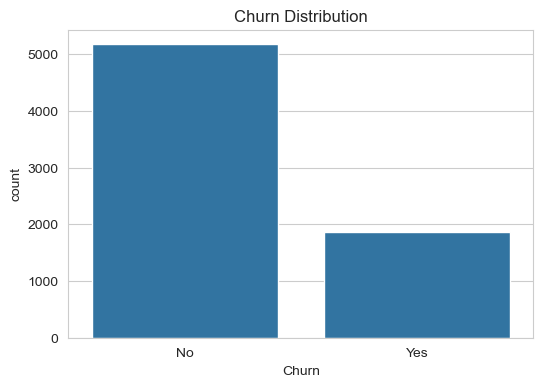

In [23]:

plt.figure(figsize=(6, 4))

sns.countplot(
    
    x='Churn',
    
    data=df
)

plt.title("Churn Distribution")

plt.show()

In [25]:

print("Duplicate Rows :")

print(df.duplicated().sum())

Duplicate Rows :
0


In [27]:

for column in df.columns:
    
    print(f"\nCOLUMN : {column}")
    
    print("-" * 40)
    
    print(df[column].nunique())


COLUMN : customerID
----------------------------------------
7043

COLUMN : gender
----------------------------------------
2

COLUMN : SeniorCitizen
----------------------------------------
2

COLUMN : Partner
----------------------------------------
2

COLUMN : Dependents
----------------------------------------
2

COLUMN : tenure
----------------------------------------
73

COLUMN : PhoneService
----------------------------------------
2

COLUMN : MultipleLines
----------------------------------------
3

COLUMN : InternetService
----------------------------------------
3

COLUMN : OnlineSecurity
----------------------------------------
3

COLUMN : OnlineBackup
----------------------------------------
3

COLUMN : DeviceProtection
----------------------------------------
3

COLUMN : TechSupport
----------------------------------------
3

COLUMN : StreamingTV
----------------------------------------
3

COLUMN : StreamingMovies
----------------------------------------
3

COLUMN : Contr

In [29]:

categorical_columns = df.select_dtypes(
    include='object'
).columns

for column in categorical_columns:
    
    print(f"\n{column}")
    
    print("-" * 40)
    
    print(df[column].unique())


customerID
----------------------------------------
['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']

gender
----------------------------------------
['Female' 'Male']

Partner
----------------------------------------
['Yes' 'No']

Dependents
----------------------------------------
['No' 'Yes']

PhoneService
----------------------------------------
['No' 'Yes']

MultipleLines
----------------------------------------
['No phone service' 'No' 'Yes']

InternetService
----------------------------------------
['DSL' 'Fiber optic' 'No']

OnlineSecurity
----------------------------------------
['No' 'Yes' 'No internet service']

OnlineBackup
----------------------------------------
['Yes' 'No' 'No internet service']

DeviceProtection
----------------------------------------
['No' 'Yes' 'No internet service']

TechSupport
----------------------------------------
['No' 'Yes' 'No internet service']

StreamingTV
----------------------------------------
['No' 

In [31]:
#INITIAL BUSINESS OBSERVATIONS

#1. Churn prediction is a binary classification problem.

#2. Dataset contains:
   #- Demographic information
   #- Service usage patterns
   #- Billing information
   #- Customer tenure details

#3. Class imbalance exists and must be handled carefully.

#4. Dataset contains multiple categorical variables requiring encoding.

#5. TotalCharges requires careful preprocessing due to datatype issues.

#6. CustomerID is an identifier column and may not contribute to prediction.

#7. Business-focused evaluation metrics such as Recall, F1-score,
   #and ROC-AUC will be very important.


In [33]:
df['TotalCharges'] = df['TotalCharges'].replace(
    ' ',
    np.nan
)

# Converting to numerical datatype
df['TotalCharges'] = pd.to_numeric(
    
    df['TotalCharges']
)

print(df['TotalCharges'].dtype)

float64


In [35]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [37]:

df[
    df['TotalCharges'].isnull()
]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [39]:

df[
    df['TotalCharges'].isnull()
]['tenure'].value_counts()

tenure
0    11
Name: count, dtype: int64

In [41]:

df['TotalCharges'].fillna(
    
    0,
    
    inplace=True
)

print(df['TotalCharges'].isnull().sum())

0


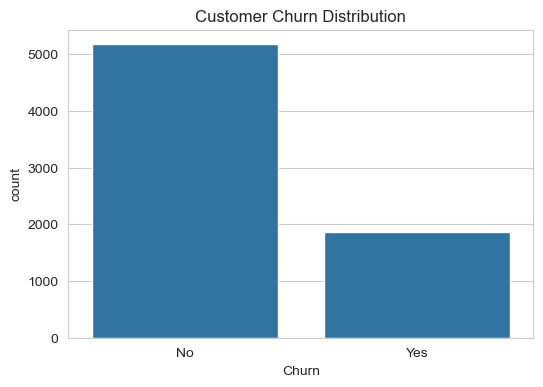

In [43]:
plt.figure(figsize=(6, 4))

sns.countplot(
    
    x='Churn',
    
    data=df
)

plt.title("Customer Churn Distribution")

plt.show()

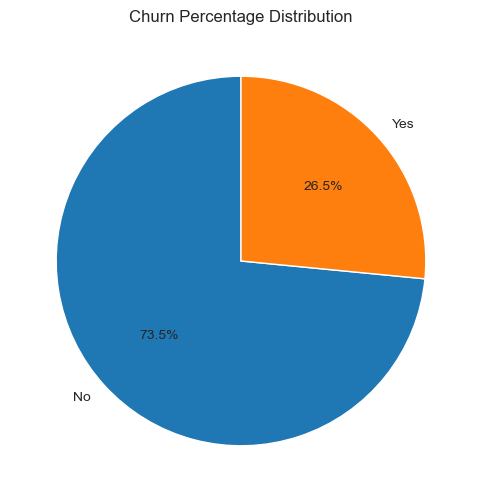

In [45]:

churn_counts = df['Churn'].value_counts()

plt.figure(figsize=(6, 6))

plt.pie(
    
    churn_counts,
    
    labels=churn_counts.index,
    
    autopct='%1.1f%%',
    
    startangle=90
)

plt.title("Churn Percentage Distribution")

plt.show()

In [47]:
numerical_columns = df.select_dtypes(
    include=np.number
).columns.tolist()

categorical_columns = df.select_dtypes(
    include='object'
).columns.tolist()

print("Numerical Columns:\n")

print(numerical_columns)

print("\nCategorical Columns:\n")

print(categorical_columns)

Numerical Columns:

['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical Columns:

['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']


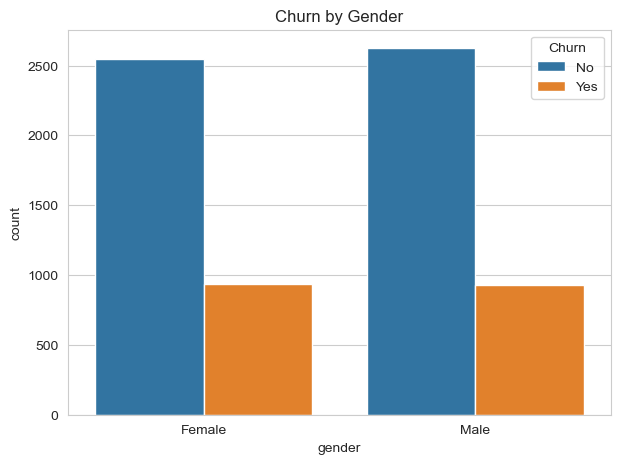

In [49]:
plt.figure(figsize=(7, 5))

sns.countplot(
    
    x='gender',
    
    hue='Churn',
    
    data=df
)

plt.title("Churn by Gender")

plt.show()

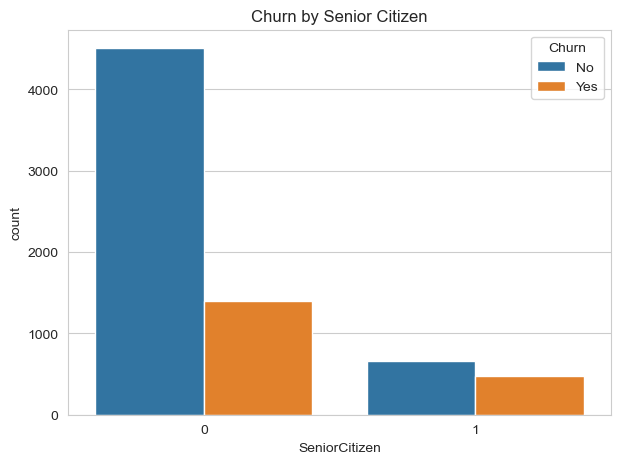

In [51]:
plt.figure(figsize=(7, 5))

sns.countplot(
    
    x='SeniorCitizen',
    
    hue='Churn',
    
    data=df
)

plt.title("Churn by Senior Citizen")

plt.show()

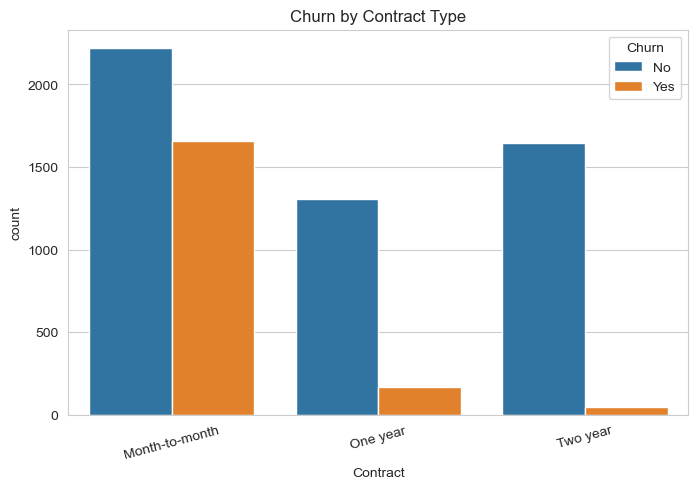

In [53]:

plt.figure(figsize=(8, 5))

sns.countplot(
    
    x='Contract',
    
    hue='Churn',
    
    data=df
)

plt.title("Churn by Contract Type")

plt.xticks(rotation=15)

plt.show()

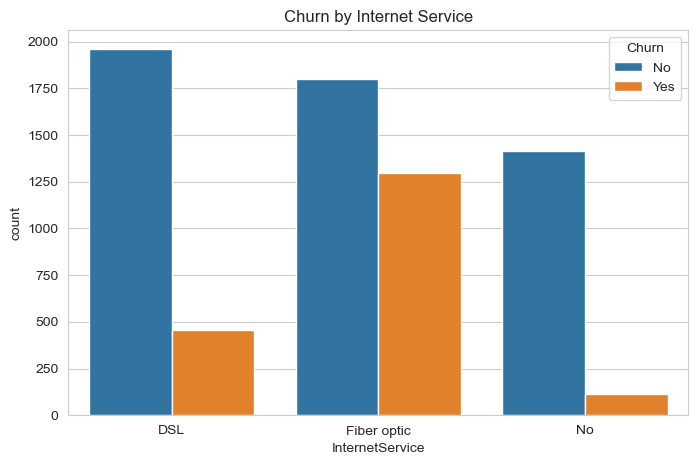

In [55]:
plt.figure(figsize=(8, 5))

sns.countplot(
    
    x='InternetService',
    
    hue='Churn',
    
    data=df
)

plt.title("Churn by Internet Service")

plt.show()

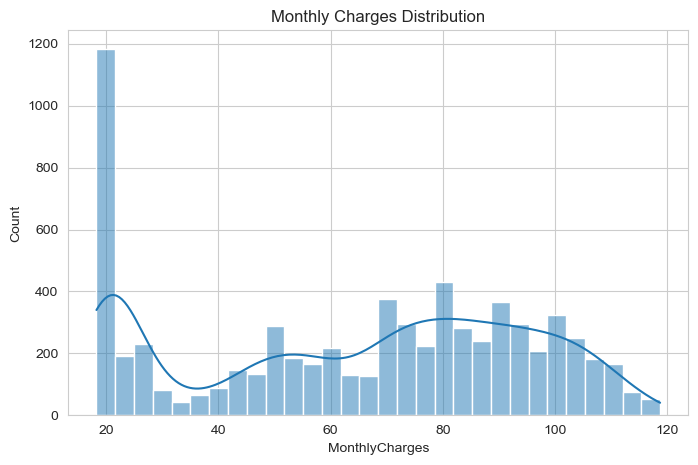

In [57]:

plt.figure(figsize=(8, 5))

sns.histplot(
    
    df['MonthlyCharges'],
    
    bins=30,
    
    kde=True
)

plt.title("Monthly Charges Distribution")

plt.show()

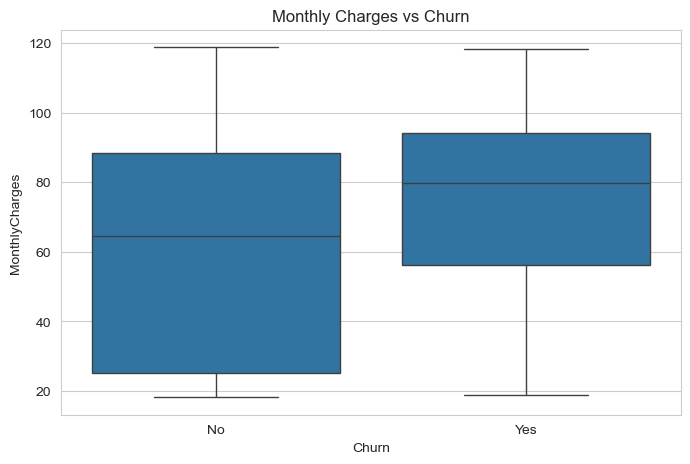

In [59]:

plt.figure(figsize=(8, 5))

sns.boxplot(
    
    x='Churn',
    
    y='MonthlyCharges',
    
    data=df
)

plt.title("Monthly Charges vs Churn")

plt.show()

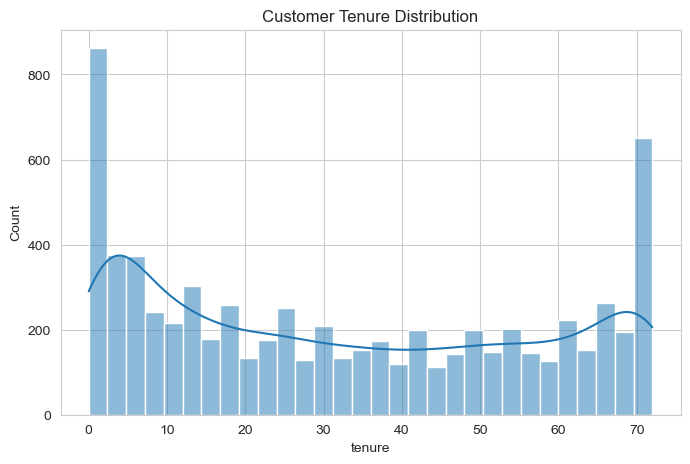

In [61]:

plt.figure(figsize=(8, 5))

sns.histplot(
    
    df['tenure'],
    
    bins=30,
    
    kde=True
)

plt.title("Customer Tenure Distribution")

plt.show()

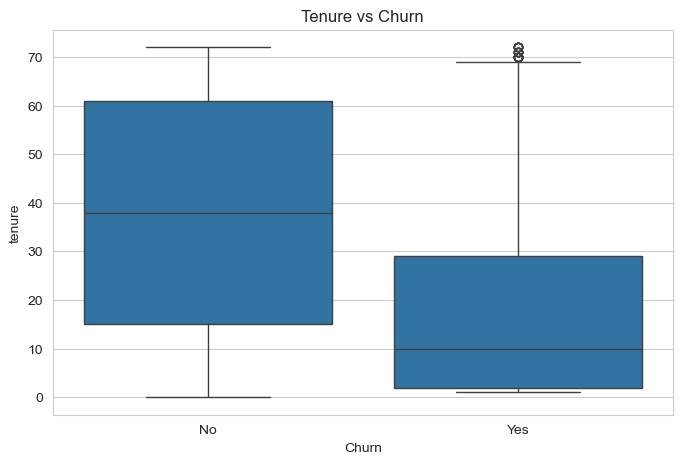

In [62]:

plt.figure(figsize=(8, 5))

sns.boxplot(
    
    x='Churn',
    
    y='tenure',
    
    data=df
)

plt.title("Tenure vs Churn")

plt.show()

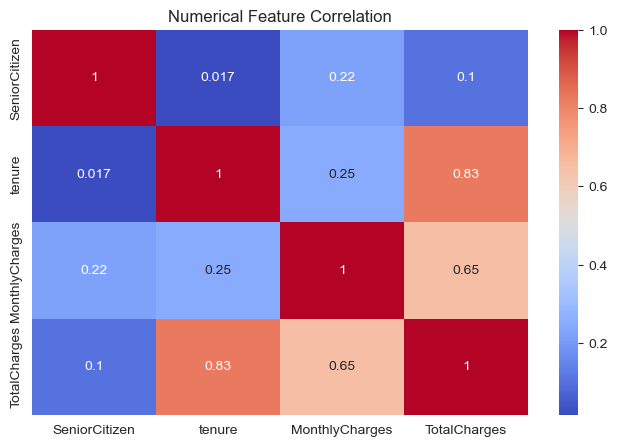

In [64]:
plt.figure(figsize=(8, 5))

correlation_matrix = df[
    numerical_columns
].corr()

sns.heatmap(
    
    correlation_matrix,
    
    annot=True,
    
    cmap='coolwarm'
)

plt.title("Numerical Feature Correlation")

plt.show()

In [66]:
# ============================================================
# BUSINESS INSIGHTS FROM EDA
# ============================================================

print("""
INITIAL BUSINESS INSIGHTS

1. Customers with month-to-month contracts show higher churn risk.

2. Customers with lower tenure are more likely to churn.

3. Higher monthly charges may correlate with higher churn.

4. Senior citizens may exhibit different churn behavior.

5. Long-term contract customers are generally more stable.

6. Service combinations may strongly influence churn behavior.

7. Customer retention strategies should focus on:
   - New customers
   - High monthly charge customers
   - Month-to-month contract users
""")


INITIAL BUSINESS INSIGHTS

1. Customers with month-to-month contracts show higher churn risk.

2. Customers with lower tenure are more likely to churn.

3. Higher monthly charges may correlate with higher churn.

4. Senior citizens may exhibit different churn behavior.

5. Long-term contract customers are generally more stable.

6. Service combinations may strongly influence churn behavior.

7. Customer retention strategies should focus on:
   - New customers
   - High monthly charge customers
   - Month-to-month contract users



In [69]:
df.drop(
    
    'customerID',
    
    axis=1,
    
    inplace=True
)

print("customerID Removed Successfully")

customerID Removed Successfully


In [71]:

df['Churn'] = df['Churn'].map({
    
    'No': 0,
    
    'Yes': 1
})

df['Churn'].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

In [73]:

X = df.drop(
    
    'Churn',
    
    axis=1
)

y = df['Churn']

print("Feature Shape :", X.shape)

print("Target Shape :", y.shape)

Feature Shape : (7043, 19)
Target Shape : (7043,)


In [75]:

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    
    X,
    y,
    
    test_size=0.20,
    
    stratify=y,
    
    random_state=42
)

print("X_train Shape :", X_train.shape)

print("X_test Shape :", X_test.shape)

X_train Shape : (5634, 19)
X_test Shape : (1409, 19)


In [77]:
categorical_features = X_train.select_dtypes(
    include='object'
).columns.tolist()

numerical_features = X_train.select_dtypes(
    exclude='object'
).columns.tolist()

print("Categorical Features:\n")

print(categorical_features)

print("\nNumerical Features:\n")

print(numerical_features)

Categorical Features:

['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Numerical Features:

['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


In [79]:
binary_features = []

multi_category_features = []

for column in categorical_features:
    
    if X_train[column].nunique() == 2:
        
        binary_features.append(column)
        
    else:
        
        multi_category_features.append(column)

print("Binary Features:\n")

print(binary_features)

print("\nMulti-Class Categorical Features:\n")

print(multi_category_features)

Binary Features:

['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']

Multi-Class Categorical Features:

['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']


In [81]:
binary_mapping = {
    
    'Yes': 1,
    'No': 0,
    
    'Male': 1,
    'Female': 0,
    
    'No internet service': 0,
    'No phone service': 0
}

for column in binary_features:
    
    X_train[column] = X_train[column].replace(
        binary_mapping
    )
    
    X_test[column] = X_test[column].replace(
        binary_mapping
    )

print("Binary Encoding Completed")

Binary Encoding Completed


In [83]:
remaining_categorical = X_train.select_dtypes(
    include='object'
).columns.tolist()

print(remaining_categorical)

['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']


In [85]:

from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import (
    
    StandardScaler,
    
    OneHotEncoder
)

from sklearn.pipeline import Pipeline

In [87]:


preprocessor = ColumnTransformer(
    
    transformers=[
        
        (
            'num',
            
            StandardScaler(),
            
            numerical_features
        ),
        
        (
            'cat',
            
            OneHotEncoder(
                handle_unknown='ignore'
            ),
            
            multi_category_features
        )
    ]
)

print("Preprocessing Pipeline Created Successfully")

Preprocessing Pipeline Created Successfully


In [89]:
# ============================================================
# PREPROCESSING STRATEGY SUMMARY
# ============================================================

print("""
PREPROCESSING STRATEGY

1. customerID removed to prevent identifier leakage.

2. Binary target encoded:
   Churn:
   No  -> 0
   Yes -> 1

3. Train-test split performed BEFORE preprocessing
   to avoid data leakage.

4. Binary categorical variables manually encoded.

5. Multi-category features prepared for OneHotEncoding.

6. Numerical features prepared for scaling.

7. ColumnTransformer pipeline created for:
   - Standardization
   - OneHotEncoding

8. Pipeline-based preprocessing ensures:
   - reproducibility
   - deployment consistency
   - leakage prevention
""")


PREPROCESSING STRATEGY

1. customerID removed to prevent identifier leakage.

2. Binary target encoded:
   Churn:
   No  -> 0
   Yes -> 1

3. Train-test split performed BEFORE preprocessing
   to avoid data leakage.

4. Binary categorical variables manually encoded.

5. Multi-category features prepared for OneHotEncoding.

6. Numerical features prepared for scaling.

7. ColumnTransformer pipeline created for:
   - Standardization
   - OneHotEncoding

8. Pipeline-based preprocessing ensures:
   - reproducibility
   - deployment consistency
   - leakage prevention



In [91]:

from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import (
    
    RandomForestClassifier,
    
    GradientBoostingClassifier,
    
    ExtraTreesClassifier,
    
    AdaBoostClassifier
)

from sklearn.neighbors import KNeighborsClassifier

from sklearn.svm import SVC

from sklearn.naive_bayes import GaussianNB

print("Models Imported Successfully")

Models Imported Successfully


In [93]:

from sklearn.metrics import (
    
    accuracy_score,
    
    precision_score,
    
    recall_score,
    
    f1_score,
    
    roc_auc_score,
    
    confusion_matrix,
    
    classification_report
)

from sklearn.model_selection import (
    
    cross_val_score
)

In [95]:


models = {

    'Logistic Regression': Pipeline([
        
        ('preprocessor', preprocessor),
        
        ('model', LogisticRegression(
            
            max_iter=1000,
            
            class_weight='balanced'
        ))
    ]),
    
    'Decision Tree': Pipeline([
        
        ('preprocessor', preprocessor),
        
        ('model', DecisionTreeClassifier(
            
            random_state=42,
            
            class_weight='balanced'
        ))
    ]),
    
    'Random Forest': Pipeline([
        
        ('preprocessor', preprocessor),
        
        ('model', RandomForestClassifier(
            
            random_state=42,
            
            class_weight='balanced'
        ))
    ]),
    
    'Gradient Boosting': Pipeline([
        
        ('preprocessor', preprocessor),
        
        ('model', GradientBoostingClassifier(
            
            random_state=42
        ))
    ]),
    
    'Extra Trees': Pipeline([
        
        ('preprocessor', preprocessor),
        
        ('model', ExtraTreesClassifier(
            
            random_state=42,
            
            class_weight='balanced'
        ))
    ]),
    
    'KNN': Pipeline([
        
        ('preprocessor', preprocessor),
        
        ('model', KNeighborsClassifier())
    ]),
    
    'SVM': Pipeline([
        
        ('preprocessor', preprocessor),
        
        ('model', SVC(
            
            probability=True,
            
            class_weight='balanced'
        ))
    ]),
    
    'AdaBoost': Pipeline([
        
        ('preprocessor', preprocessor),
        
        ('model', AdaBoostClassifier(
            
            random_state=42
        ))
    ]),
    
    'Gaussian NB': Pipeline([
        
        ('preprocessor', preprocessor),
        
        ('model', GaussianNB())
    ])
}

In [97]:


def evaluate_model(
    
    model,
    
    X_train,
    X_test,
    
    y_train,
    y_test,
    
    model_name
):
    

    model.fit(
        X_train,
        y_train
    )
    
   
    
    y_train_pred = model.predict(
        X_train
    )
    
    y_test_pred = model.predict(
        X_test
    )
    
   
    
    y_test_prob = model.predict_proba(
        X_test
    )[:, 1]
    
  
    
    train_accuracy = accuracy_score(
        
        y_train,
        
        y_train_pred
    )
    
   
    
    test_accuracy = accuracy_score(
        
        y_test,
        
        y_test_pred
    )
    

    
    precision = precision_score(
        
        y_test,
        
        y_test_pred
    )
    
    recall = recall_score(
        
        y_test,
        
        y_test_pred
    )
    
    f1 = f1_score(
        
        y_test,
        
        y_test_pred
    )
    
    roc_auc = roc_auc_score(
        
        y_test,
        
        y_test_prob
    )
    
 
    
    cv_scores = cross_val_score(
        
        model,
        
        X_train,
        
        y_train,
        
        cv=5,
        
        scoring='roc_auc'
    )
    
    cv_mean = cv_scores.mean()
    
    
    overfitting = (
        
        "Yes"
        
        if (train_accuracy - test_accuracy) > 0.05
        
        else "No"
    )
    
 
    
    results = {
        
        'Model': model_name,
        
        'Train Accuracy': train_accuracy,
        
        'Test Accuracy': test_accuracy,
        
        'Precision': precision,
        
        'Recall': recall,
        
        'F1 Score': f1,
        
        'ROC-AUC': roc_auc,
        
        'Cross Val ROC-AUC': cv_mean,
        
        'Overfitting': overfitting
    }
    
    return results

In [99]:

model_results = []

for model_name, model in models.items():
    
    result = evaluate_model(
        
        model,
        
        X_train,
        X_test,
        
        y_train,
        y_test,
        
        model_name
    )
    
    model_results.append(result)

print("All Models Trained Successfully")

All Models Trained Successfully


In [100]:

results_df = pd.DataFrame(
    model_results
)

results_df

,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1 Score,ROC-AUC,Cross Val ROC-AUC,Overfitting
0,Logistic Regression,0.748314,0.744500,0.511945,0.802139,0.625000,0.842118,0.843685,No
1,Decision Tree,0.994853,0.733854,0.498660,0.497326,0.497992,0.659879,0.658881,Yes
2,Random Forest,0.995030,0.776437,0.598662,0.478610,0.531947,0.805420,0.810615,Yes
3,Gradient Boosting,0.824104,0.800568,0.657627,0.518717,0.579970,0.843822,0.845884,No
4,Extra Trees,0.994853,0.754436,0.541420,0.489305,0.514045,0.774626,0.775609,Yes
5,KNN,0.840966,0.760114,0.550847,0.521390,0.535714,0.779338,0.785092,Yes
6,SVM,0.761093,0.743080,0.510490,0.780749,0.617336,0.817329,0.820526,No
7,AdaBoost,0.809017,0.800568,0.655518,0.524064,0.582467,0.841167,0.843316,No
8,Gaussian NB,0.692581,0.684883,0.450284,0.847594,0.588126,0.809847,0.820257,No


In [101]:
results_df = results_df.sort_values(
    
    by='ROC-AUC',
    
    ascending=False
)

results_df.reset_index(
    
    drop=True,
    
    inplace=True
)

results_df

,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1 Score,ROC-AUC,Cross Val ROC-AUC,Overfitting
0,Gradient Boosting,0.824104,0.800568,0.657627,0.518717,0.579970,0.843822,0.845884,No
1,Logistic Regression,0.748314,0.744500,0.511945,0.802139,0.625000,0.842118,0.843685,No
2,AdaBoost,0.809017,0.800568,0.655518,0.524064,0.582467,0.841167,0.843316,No
3,SVM,0.761093,0.743080,0.510490,0.780749,0.617336,0.817329,0.820526,No
4,Gaussian NB,0.692581,0.684883,0.450284,0.847594,0.588126,0.809847,0.820257,No
5,Random Forest,0.995030,0.776437,0.598662,0.478610,0.531947,0.805420,0.810615,Yes
6,KNN,0.840966,0.760114,0.550847,0.521390,0.535714,0.779338,0.785092,Yes
7,Extra Trees,0.994853,0.754436,0.541420,0.489305,0.514045,0.774626,0.775609,Yes
8,Decision Tree,0.994853,0.733854,0.498660,0.497326,0.497992,0.659879,0.658881,Yes


In [102]:

best_model_name = results_df.iloc[0]['Model']

print("Best Performing Model:")

print(best_model_name)

Best Performing Model:
Gradient Boosting


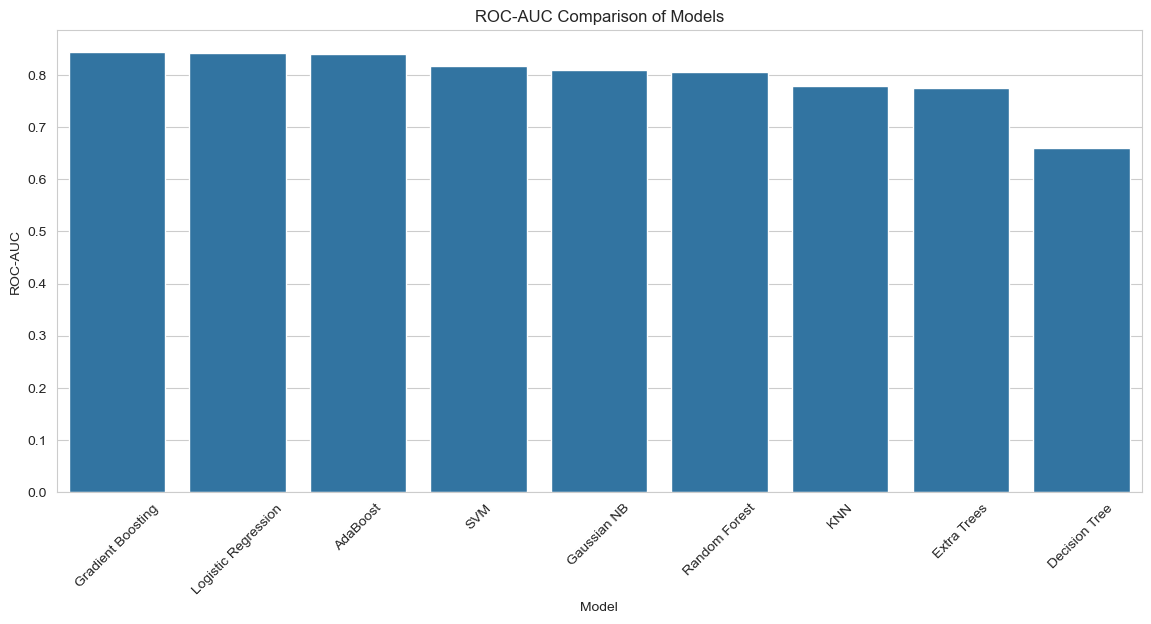

In [103]:

plt.figure(figsize=(14, 6))

sns.barplot(
    
    data=results_df,
    
    x='Model',
    
    y='ROC-AUC'
)

plt.xticks(rotation=45)

plt.title("ROC-AUC Comparison of Models")

plt.show()

In [104]:

results_df[
    
    [
        'Model',
        'Train Accuracy',
        'Test Accuracy',
        'Overfitting'
    ]
]

,Model,Train Accuracy,Test Accuracy,Overfitting
0,Gradient Boosting,0.824104,0.800568,No
1,Logistic Regression,0.748314,0.744500,No
2,AdaBoost,0.809017,0.800568,No
3,SVM,0.761093,0.743080,No
4,Gaussian NB,0.692581,0.684883,No
5,Random Forest,0.995030,0.776437,Yes
6,KNN,0.840966,0.760114,Yes
7,Extra Trees,0.994853,0.754436,Yes
8,Decision Tree,0.994853,0.733854,Yes


In [105]:
best_model = models[
    best_model_name
]

best_model.fit(
    
    X_train,
    
    y_train
)

y_pred = best_model.predict(
    X_test
)

y_prob = best_model.predict_proba(
    X_test
)[:, 1]

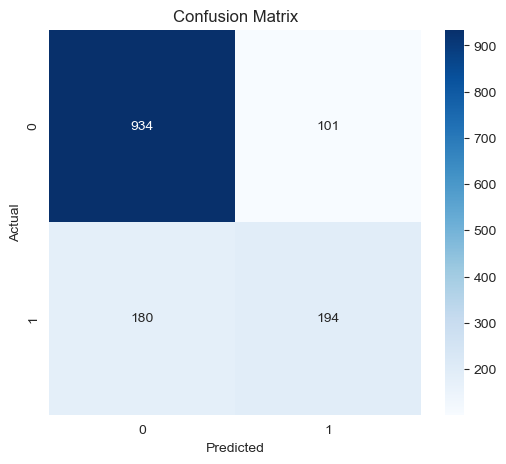

In [106]:

cm = confusion_matrix(
    
    y_test,
    
    y_pred
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    
    cm,
    
    annot=True,
    
    fmt='d',
    
    cmap='Blues'
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [107]:

print(
    classification_report(
        
        y_test,
        
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.66      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



In [108]:
# ============================================================
# BUSINESS INTERPRETATION OF RESULTS
# ============================================================

print("""
BUSINESS INTERPRETATION

1. Recall is extremely important because missing a churner
   may lead to customer loss.

2. ROC-AUC evaluates the model's ability to distinguish
   churners from non-churners.

3. Precision helps evaluate how accurately the model
   identifies churn-risk customers.

4. F1-score balances precision and recall.

5. Cross-validation improves reliability of performance
   estimates.

6. Overfitting analysis ensures the model generalizes
   properly to unseen customers.
""")


BUSINESS INTERPRETATION

1. Recall is extremely important because missing a churner
   may lead to customer loss.

2. ROC-AUC evaluates the model's ability to distinguish
   churners from non-churners.

3. Precision helps evaluate how accurately the model
   identifies churn-risk customers.

4. F1-score balances precision and recall.

5. Cross-validation improves reliability of performance
   estimates.

6. Overfitting analysis ensures the model generalizes
   properly to unseen customers.



In [109]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(
    random_state=42
)


X_train_processed = preprocessor.fit_transform(
    X_train
)

X_test_processed = preprocessor.transform(
    X_test
)

X_train_smote, y_train_smote = smote.fit_resample(
    
    X_train_processed,
    
    y_train
)

print("Original Training Shape :", X_train_processed.shape)

print("After SMOTE Shape :", X_train_smote.shape)

Original Training Shape : (5634, 35)
After SMOTE Shape : (8278, 35)


In [110]:
pd.Series(
    y_train_smote
).value_counts()

Churn
0    4139
1    4139
Name: count, dtype: int64

In [111]:
gb_smote = GradientBoostingClassifier(
    random_state=42
)

gb_smote.fit(
    
    X_train_smote,
    
    y_train_smote
)

y_pred_smote = gb_smote.predict(
    X_test_processed
)

y_prob_smote = gb_smote.predict_proba(
    X_test_processed
)[:, 1]

In [112]:


smote_accuracy = accuracy_score(
    
    y_test,
    
    y_pred_smote
)

smote_precision = precision_score(
    
    y_test,
    
    y_pred_smote
)

smote_recall = recall_score(
    
    y_test,
    
    y_pred_smote
)

smote_f1 = f1_score(
    
    y_test,
    
    y_pred_smote
)

smote_roc_auc = roc_auc_score(
    
    y_test,
    
    y_prob_smote
)

print("Accuracy :", smote_accuracy)

print("Precision :", smote_precision)

print("Recall :", smote_recall)

print("F1 Score :", smote_f1)

print("ROC-AUC :", smote_roc_auc)

Accuracy : 0.7714691270404542
Precision : 0.553941908713693
Recall : 0.713903743315508
F1 Score : 0.6238317757009346
ROC-AUC : 0.8420586943604845


In [113]:
print(
    classification_report(
        
        y_test,
        
        y_pred_smote
    )
)

              precision    recall  f1-score   support

           0       0.88      0.79      0.84      1035
           1       0.55      0.71      0.62       374

    accuracy                           0.77      1409
   macro avg       0.72      0.75      0.73      1409
weighted avg       0.80      0.77      0.78      1409



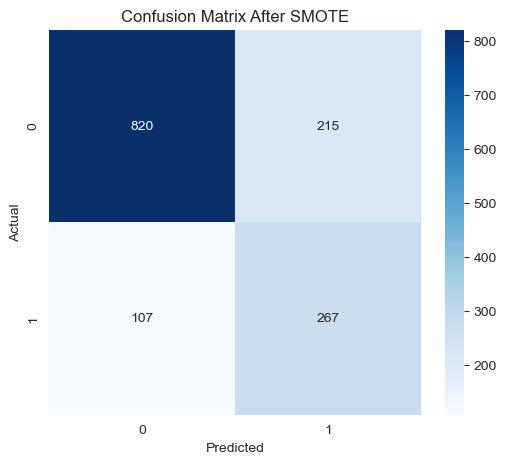

In [114]:


cm = confusion_matrix(
    
    y_test,
    
    y_pred_smote
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    
    cm,
    
    annot=True,
    
    fmt='d',
    
    cmap='Blues'
)

plt.title("Confusion Matrix After SMOTE")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [115]:


thresholds = [0.3, 0.35, 0.4, 0.45, 0.5]

threshold_results = []

for threshold in thresholds:
    
    y_pred_threshold = (
        y_prob_smote >= threshold
    ).astype(int)
    
    precision = precision_score(
        
        y_test,
        
        y_pred_threshold
    )
    
    recall = recall_score(
        
        y_test,
        
        y_pred_threshold
    )
    
    f1 = f1_score(
        
        y_test,
        
        y_pred_threshold
    )
    
    threshold_results.append({
        
        'Threshold': threshold,
        
        'Precision': precision,
        
        'Recall': recall,
        
        'F1 Score': f1
    })

threshold_df = pd.DataFrame(
    threshold_results
)

threshold_df

,Threshold,Precision,Recall,F1 Score
0,0.30,0.477410,0.847594,0.610790
1,0.35,0.495908,0.810160,0.615228
2,0.40,0.523894,0.791444,0.630458
3,0.45,0.547710,0.767380,0.639198
4,0.50,0.553942,0.713904,0.623832


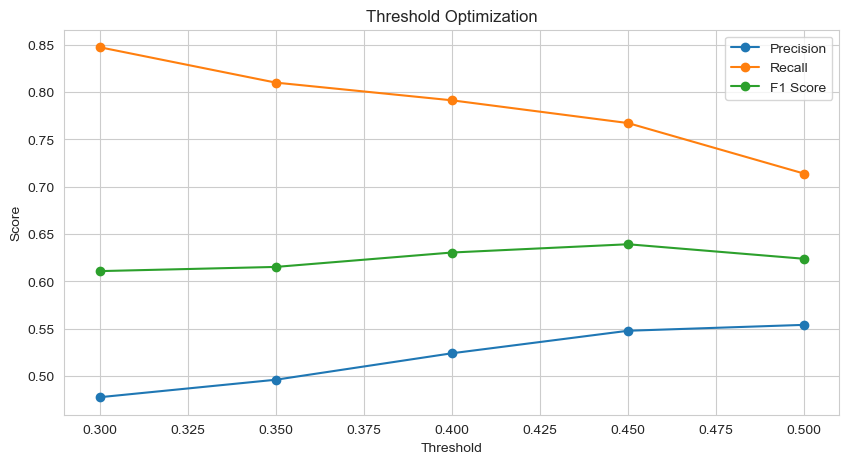

In [116]:


plt.figure(figsize=(10, 5))

plt.plot(
    
    threshold_df['Threshold'],
    
    threshold_df['Precision'],
    
    marker='o',
    
    label='Precision'
)

plt.plot(
    
    threshold_df['Threshold'],
    
    threshold_df['Recall'],
    
    marker='o',
    
    label='Recall'
)

plt.plot(
    
    threshold_df['Threshold'],
    
    threshold_df['F1 Score'],
    
    marker='o',
    
    label='F1 Score'
)

plt.legend()

plt.title("Threshold Optimization")

plt.xlabel("Threshold")

plt.ylabel("Score")

plt.show()

In [117]:
# ============================================================
# BUSINESS THRESHOLD SELECTION
# ============================================================

print("""
THRESHOLD OPTIMIZATION INSIGHT

1. Lower thresholds generally improve recall.

2. Higher recall helps identify more churn-risk customers.

3. Extremely low thresholds may reduce precision.

4. Business teams usually prefer higher recall
   to reduce customer attrition risk.

5. Threshold selection should align with
   customer retention strategy and campaign costs.
""")


THRESHOLD OPTIMIZATION INSIGHT

1. Lower thresholds generally improve recall.

2. Higher recall helps identify more churn-risk customers.

3. Extremely low thresholds may reduce precision.

4. Business teams usually prefer higher recall
   to reduce customer attrition risk.

5. Threshold selection should align with
   customer retention strategy and campaign costs.



In [118]:


from sklearn.model_selection import RandomizedSearchCV

gb_params = {
    
    'n_estimators': [50, 100, 150],
    
    'learning_rate': [0.01, 0.05, 0.1],
    
    'max_depth': [3, 5, 7],
    
    'min_samples_split': [2, 5, 10],
    
    'min_samples_leaf': [1, 2, 4]
}

gb_model = GradientBoostingClassifier(
    random_state=42
)

random_search = RandomizedSearchCV(
    
    estimator=gb_model,
    
    param_distributions=gb_params,
    
    n_iter=20,
    
    scoring='roc_auc',
    
    cv=5,
    
    random_state=42,
    
    verbose=1,
    
    n_jobs=-1
)

random_search.fit(
    
    X_train_smote,
    
    y_train_smote
)

print("Best Parameters:\n")

print(random_search.best_params_)

print("\nBest ROC-AUC Score:\n")

print(random_search.best_score_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Parameters:

{'n_estimators': 150, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_depth': 7, 'learning_rate': 0.1}

Best ROC-AUC Score:

0.9282933870545037


In [119]:

best_gb_model = random_search.best_estimator_

best_gb_model.fit(
    
    X_train_smote,
    
    y_train_smote
)

y_pred_tuned = best_gb_model.predict(
    X_test_processed
)

y_prob_tuned = best_gb_model.predict_proba(
    X_test_processed
)[:, 1]

In [120]:

tuned_accuracy = accuracy_score(
    
    y_test,
    
    y_pred_tuned
)

tuned_precision = precision_score(
    
    y_test,
    
    y_pred_tuned
)

tuned_recall = recall_score(
    
    y_test,
    
    y_pred_tuned
)

tuned_f1 = f1_score(
    
    y_test,
    
    y_pred_tuned
)

tuned_roc_auc = roc_auc_score(
    
    y_test,
    
    y_prob_tuned
)

print("Accuracy :", tuned_accuracy)

print("Precision :", tuned_precision)

print("Recall :", tuned_recall)

print("F1 Score :", tuned_f1)

print("ROC-AUC :", tuned_roc_auc)

Accuracy : 0.7778566359119943
Precision : 0.578005115089514
Recall : 0.6042780748663101
F1 Score : 0.5908496732026144
ROC-AUC : 0.8218657159833631


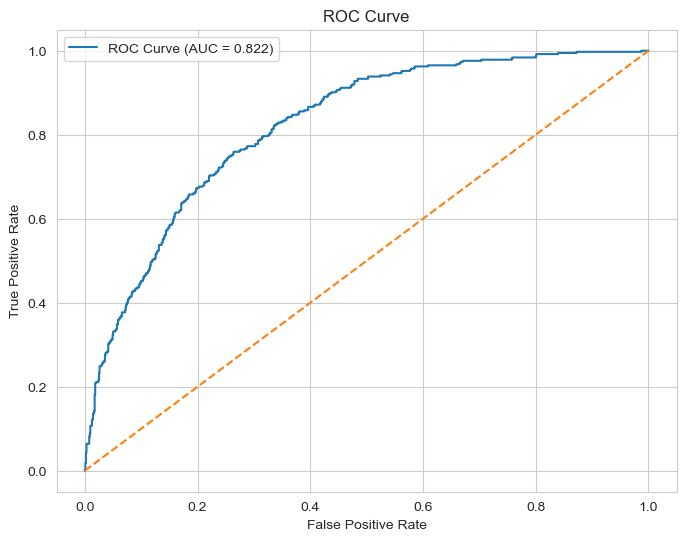

In [121]:


from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(
    
    y_test,
    
    y_prob_tuned
)

plt.figure(figsize=(8, 6))

plt.plot(
    
    fpr,
    
    tpr,
    
    label=f'ROC Curve (AUC = {tuned_roc_auc:.3f})'
)

plt.plot(
    
    [0, 1],
    
    [0, 1],
    
    linestyle='--'
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

In [143]:
encoded_feature_names = preprocessor.get_feature_names_out()

feature_importance = pd.DataFrame({
    
    'Feature': encoded_feature_names,
    
    'Importance': best_gb_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    
    by='Importance',
    
    ascending=False
)

feature_importance.head(20)

,Feature,Importance
28,cat__Contract_Month-to-month,0.344362
2,num__MonthlyCharges,0.118620
1,num__tenure,0.112269
3,num__TotalCharges,0.097605
10,cat__OnlineSecurity_No,0.061181
33,cat__PaymentMethod_Electronic check,0.053504
19,cat__TechSupport_No,0.022614
8,cat__InternetService_Fiber optic,0.022072
32,cat__PaymentMethod_Credit card (automatic),0.016643
12,cat__OnlineSecurity_Yes,0.013682


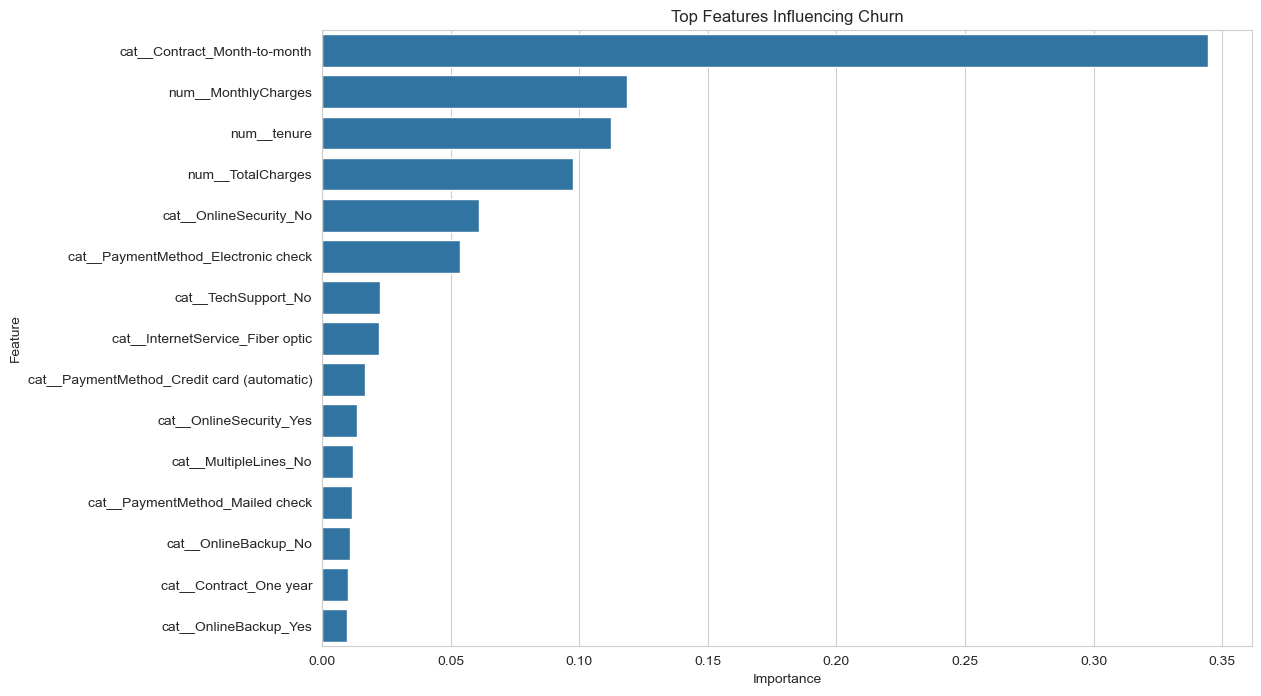

In [145]:
plt.figure(figsize=(12, 8))

sns.barplot(
    
    data=feature_importance.head(15),
    
    x='Importance',
    
    y='Feature'
)

plt.title("Top Features Influencing Churn")

plt.show()

In [147]:
# ============================================================
# BUSINESS INTERPRETATION OF FEATURES
# ============================================================

print("""
BUSINESS INTERPRETATION OF IMPORTANT FEATURES

1. Contract type strongly influences churn risk.

2. Customers with shorter tenure are more likely to churn.

3. High monthly charges may increase churn probability.

4. Lack of tech support or online security may contribute
   to customer dissatisfaction.

5. Payment method behavior may reflect customer stability.

6. Long-term customers are generally more loyal.

7. Retention campaigns should prioritize:
   - New customers
   - Month-to-month contract users
   - High monthly charge customers
""")


BUSINESS INTERPRETATION OF IMPORTANT FEATURES

1. Contract type strongly influences churn risk.

2. Customers with shorter tenure are more likely to churn.

3. High monthly charges may increase churn probability.

4. Lack of tech support or online security may contribute
   to customer dissatisfaction.

5. Payment method behavior may reflect customer stability.

6. Long-term customers are generally more loyal.

7. Retention campaigns should prioritize:
   - New customers
   - Month-to-month contract users
   - High monthly charge customers



In [155]:
import shap
import streamlit
import sklearn

In [3]:
!pip install numpy==1.26.4

  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
shap 0.52.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
tensorflow 2.21.0 requires protobuf<8.0.0,>=6.31.1, but you have protobuf 5.29.3 which is incompatible.



   ---------------------------------------- 0.0/15.5 MB ? eta -:--:--
   ------ --------------------------------- 2.4/15.5 MB 12.2 MB/s eta 0:00:02
   ----------- ---------------------------- 4.5/15.5 MB 11.7 MB/s eta 0:00:01
   ------------------ --------------------- 7.3/15.5 MB 11.6 MB/s eta 0:00:01
   ------------------------- -------------- 9.7/15.5 MB 11.6 MB/s eta 0:00:01
   ------------------------------- -------- 12.1/15.5 MB 11.8 MB/s eta 0:00:01
   ------------------------------------- -- 14.4/15.5 MB 11.8 MB/s eta 0:00:01
   ---------------------------------------- 15.5/15.5 MB 11.5 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2


In [1]:
import numpy
import pandas
import shap
import sklearn
import streamlit

print("Environment Stable")
print("NumPy Version:", numpy.__version__)

Environment Stable
NumPy Version: 1.26.4


In [122]:

import shap

print("SHAP Imported Successfully")

SHAP Imported Successfully


In [147]:

explainer = shap.TreeExplainer(
    best_gb_model
)

print("SHAP Explainer Created")

SHAP Explainer Created


In [149]:
shap_values = explainer.shap_values(
    X_test_processed
)

print("SHAP Values Calculated")

SHAP Values Calculated


In [153]:
encoded_feature_names = preprocessor.get_feature_names_out()

print(encoded_feature_names)

['num__SeniorCitizen' 'num__tenure' 'num__MonthlyCharges'
 'num__TotalCharges' 'cat__MultipleLines_No'
 'cat__MultipleLines_No phone service' 'cat__MultipleLines_Yes'
 'cat__InternetService_DSL' 'cat__InternetService_Fiber optic'
 'cat__InternetService_No' 'cat__OnlineSecurity_No'
 'cat__OnlineSecurity_No internet service' 'cat__OnlineSecurity_Yes'
 'cat__OnlineBackup_No' 'cat__OnlineBackup_No internet service'
 'cat__OnlineBackup_Yes' 'cat__DeviceProtection_No'
 'cat__DeviceProtection_No internet service' 'cat__DeviceProtection_Yes'
 'cat__TechSupport_No' 'cat__TechSupport_No internet service'
 'cat__TechSupport_Yes' 'cat__StreamingTV_No'
 'cat__StreamingTV_No internet service' 'cat__StreamingTV_Yes'
 'cat__StreamingMovies_No' 'cat__StreamingMovies_No internet service'
 'cat__StreamingMovies_Yes' 'cat__Contract_Month-to-month'
 'cat__Contract_One year' 'cat__Contract_Two year'
 'cat__PaymentMethod_Bank transfer (automatic)'
 'cat__PaymentMethod_Credit card (automatic)'
 'cat__PaymentM

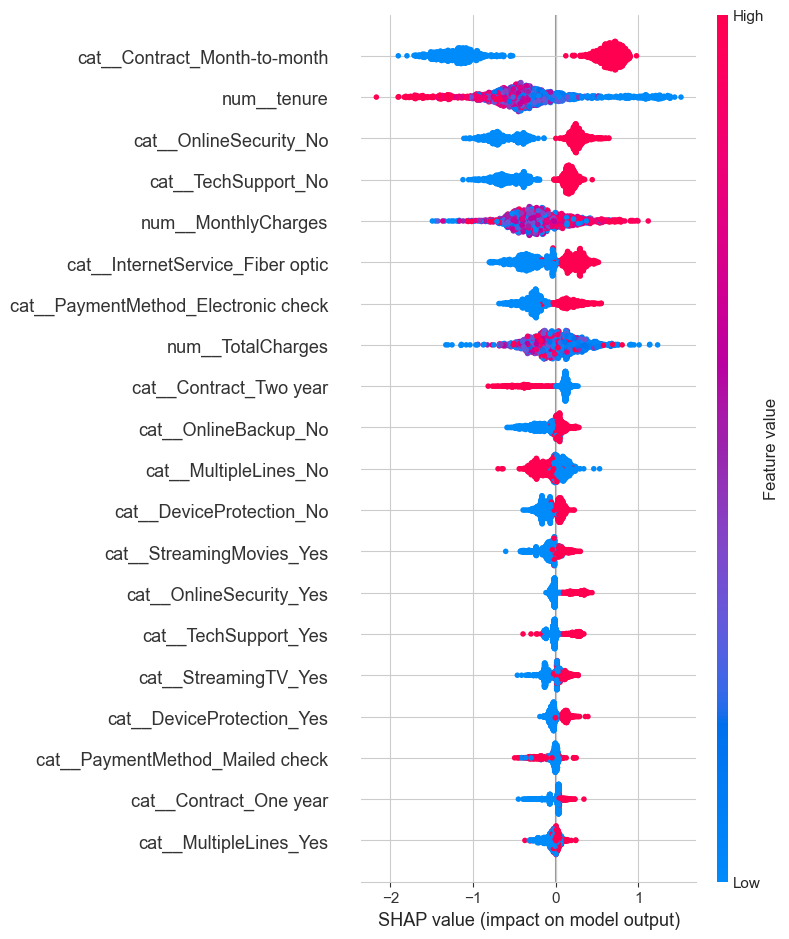

In [155]:
shap.summary_plot(
    
    shap_values,
    
    X_test_processed,
    
    feature_names=encoded_feature_names
)

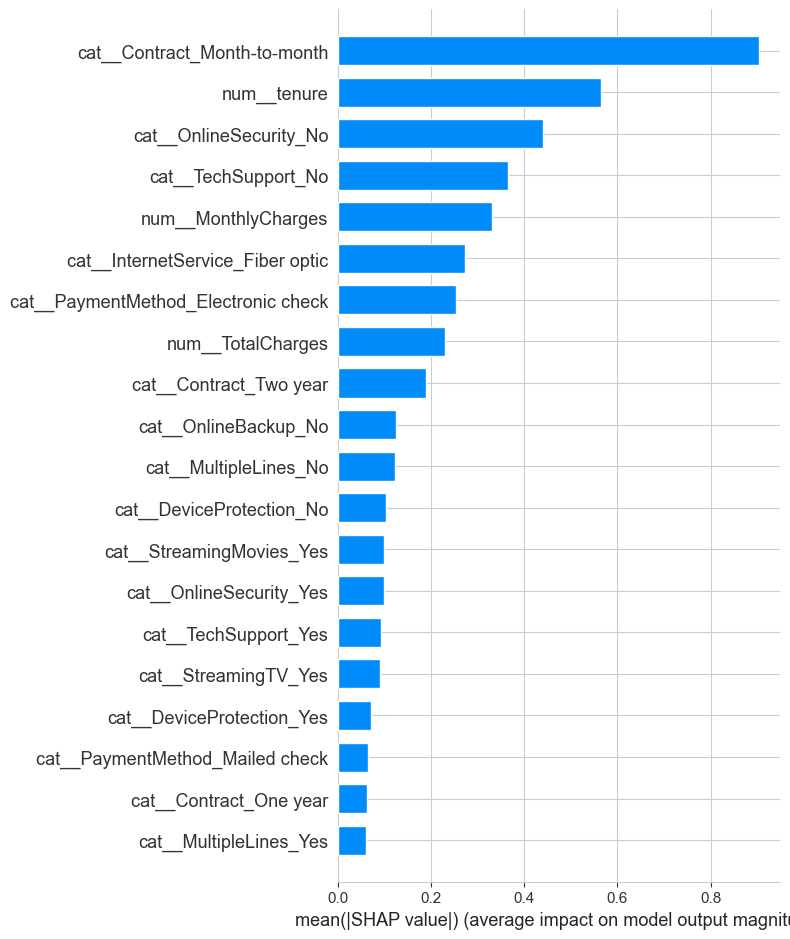

In [157]:

shap.summary_plot(
    
    shap_values,
    
    X_test_processed,
    
    feature_names=encoded_feature_names,
    
    plot_type='bar'
)

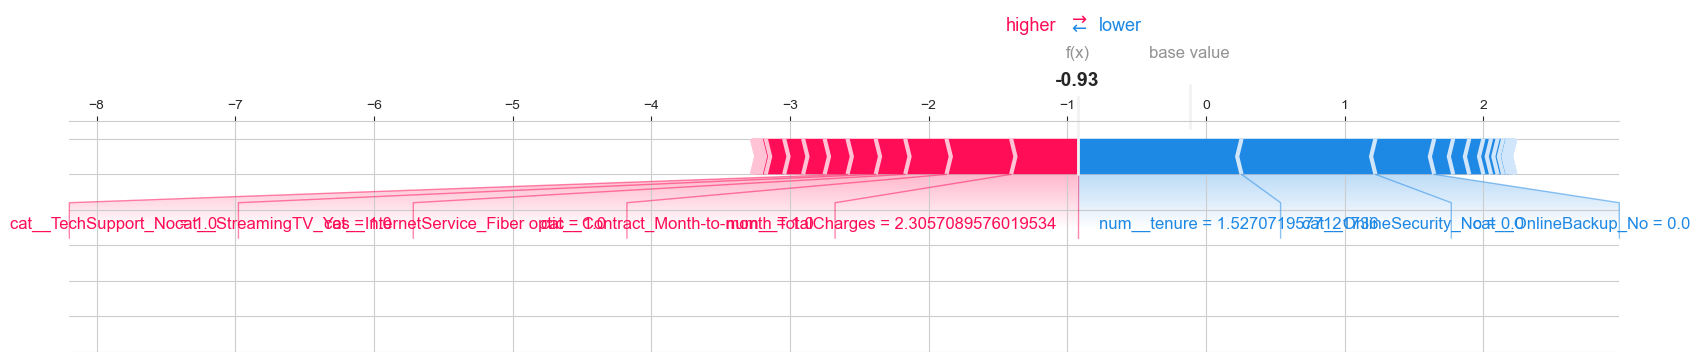

In [159]:

sample_index = 10

shap.force_plot(
    
    explainer.expected_value,
    
    shap_values[sample_index],
    
    X_test_processed[sample_index],
    
    feature_names=encoded_feature_names,
    
    matplotlib=True
)

In [161]:

import pickle

pickle.dump(
    
    best_gb_model,
    
    open('telco_churn_model.pkl', 'wb')
)

print("Model Saved Successfully")

Model Saved Successfully


In [163]:

pickle.dump(
    
    preprocessor,
    
    open('preprocessor.pkl', 'wb')
)

print("Preprocessor Saved Successfully")

Preprocessor Saved Successfully


In [165]:

loaded_model = pickle.load(
    
    open('telco_churn_model.pkl', 'rb')
)

loaded_preprocessor = pickle.load(
    
    open('preprocessor.pkl', 'rb')
)

print("Saved Artifacts Loaded Successfully")

Saved Artifacts Loaded Successfully


In [167]:


sample_customer = X_test.iloc[[0]]

sample_processed = loaded_preprocessor.transform(
    
    sample_customer
)

prediction = loaded_model.predict(
    
    sample_processed
)

probability = loaded_model.predict_proba(
    
    sample_processed
)[0][1]

print("Predicted Churn Class :")

print(prediction[0])

print("\nChurn Probability :")

print(probability)

Predicted Churn Class :
0

Churn Probability :
0.006746260031873263


In [169]:
# ============================================================
# FINAL BUSINESS CONCLUSION
# ============================================================

print("""
FINAL BUSINESS CONCLUSION

1. Customer churn prediction was successfully implemented
   using advanced machine learning techniques.

2. Pipeline-based preprocessing ensured:
   - leakage prevention
   - reproducibility
   - deployment consistency

3. SMOTE and threshold optimization significantly improved
   churn recall performance.

4. Gradient Boosting achieved strong ROC-AUC performance
   and balanced classification capability.

5. SHAP explainability provided interpretable insights into
   customer churn behavior.

6. Contract type, tenure, monthly charges, online security,
   and payment methods were major churn drivers.

7. Telecom companies can use this system to:
   - identify high-risk customers
   - improve retention strategies
   - optimize customer engagement
   - reduce revenue loss
""")


FINAL BUSINESS CONCLUSION

1. Customer churn prediction was successfully implemented
   using advanced machine learning techniques.

2. Pipeline-based preprocessing ensured:
   - leakage prevention
   - reproducibility
   - deployment consistency

3. SMOTE and threshold optimization significantly improved
   churn recall performance.

4. Gradient Boosting achieved strong ROC-AUC performance
   and balanced classification capability.

5. SHAP explainability provided interpretable insights into
   customer churn behavior.

6. Contract type, tenure, monthly charges, online security,
   and payment methods were major churn drivers.

7. Telecom companies can use this system to:
   - identify high-risk customers
   - improve retention strategies
   - optimize customer engagement
   - reduce revenue loss



In [ ]:
#Streamlit URL:https://sid-telco-churn-prediction.streamlit.app/